## **Introduction**

DeepFER: Facial Emotion Recognition Using Deep Learning is a project aimed at developing a robust and efficient system for automatically identifying human emotions from facial expressions. By leveraging advanced deep learning techniques, particularly Convolutional Neural Networks (CNNs) and Transfer Learning, DeepFER is designed to classify emotions such as happiness, sadness, anger, surprise, fear, disgust, and neutrality from facial images.

Facial emotion recognition plays a crucial role in numerous applications, including human-computer interaction, customer service, and mental health monitoring. Traditional approaches relied on handcrafted features and rule-based systems, which often struggled to generalize across diverse faces and real-world conditions. DeepFER addresses these challenges by using deep neural networks to automatically learn hierarchical features from raw image data, achieving high accuracy and real-time performance.

The ultimate goal of DeepFER is to create a versatile and practical tool that allows machines to understand and respond to human emotions, bridging the gap between artificial intelligence and empathetic human-machine interactions.

---

## **Dataset Overview**

DeepFER utilizes the **FER-2013 dataset**, a widely used benchmark for facial emotion recognition. Key characteristics of the dataset are:

* **Image Format:** 48x48 pixel grayscale images
* **Data Alignment:** Faces are automatically registered to be centered and occupy a similar area within the image
* **Dataset Size:**

  * Total: 24,400 images
  * Training set: 22,968 images
  * Public test set: 1,432 images
* **Emotion Classes:**

  1. Angry
  2. Disgust
  3. Fear
  4. Happy
  5. Sad
  6. Surprise
  7. Neutral
* **Data Characteristics:**

  * Grayscale images to simplify computational requirements
  * Poses are consistent to focus on facial expressions
  * Captures both posed and spontaneous expressions for better generalization

The FER-2013 dataset provides a solid foundation for training and evaluating the DeepFER model, allowing for accurate and real-time classification of seven distinct human emotions.




## **Installing Required Libraries**

In [1]:
# Upgrade pip (optional but recommended)
# !pip install --upgrade pip

# Install required libraries
!pip install tensorflow keras opencv-python-headless numpy pandas scikit-learn matplotlib seaborn


## **Verify Installations**

In [2]:
import tensorflow as tf
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("TensorFlow version:", tf.__version__)
print("OpenCV version:", cv2.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Seaborn version:", sns.__version__)

TensorFlow version: 2.20.0
OpenCV version: 4.13.0
NumPy version: 2.0.2
Pandas version: 2.2.2
Seaborn version: 0.13.2


In [3]:
import numpy as np             # Numerical operations
import pandas as pd            # Data manipulation / CSV I/O
import os                      # File system operations
import matplotlib.pyplot as plt  # Visualization
import seaborn as sns          # Enhanced visualization
import tensorflow as tf        # Deep learning framework
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam, RMSprop, SGD, Adamax
import cv2                     # Image processing
from tensorflow.keras.applications import VGG16, InceptionResNetV2  # For transfer learning
from keras import regularizers                                     # Optional: add weight regularization
from keras.preprocessing import image                               # Alternative to tf.keras.preprocessing
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


## **Data Ingestion**

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
!unzip "/content/drive/MyDrive/Module_5_Specialization_Computer_Vision/DeepFER_datasets.zip" -d "/content/drive/MyDrive/Module_5_Specialization_Computer_Vision/DeepFER_datasets/"

Streaming output truncated to the last 5000 lines.
 extracting: /content/drive/MyDrive/Module_5_Specialization_Computer_Vision/DeepFER_datasets/DeepFER_datasets/validation/fear/9040.jpg  
 extracting: /content/drive/MyDrive/Module_5_Specialization_Computer_Vision/DeepFER_datasets/DeepFER_datasets/validation/fear/9101.jpg  
 extracting: /content/drive/MyDrive/Module_5_Specialization_Computer_Vision/DeepFER_datasets/DeepFER_datasets/validation/fear/911.jpg  
 extracting: /content/drive/MyDrive/Module_5_Specialization_Computer_Vision/DeepFER_datasets/DeepFER_datasets/validation/fear/9179.jpg  
 extracting: /content/drive/MyDrive/Module_5_Specialization_Computer_Vision/DeepFER_datasets/DeepFER_datasets/validation/fear/9205.jpg  
 extracting: /content/drive/MyDrive/Module_5_Specialization_Computer_Vision/DeepFER_datasets/DeepFER_datasets/validation/fear/9232.jpg  
 extracting: /content/drive/MyDrive/Module_5_Specialization_Computer_Vision/DeepFER_datasets/DeepFER_datasets/validation/fear/92

In [10]:
train_dir = "/content/drive/MyDrive/Module_5_Specialization_Computer_Vision/DeepFER_datasets/DeepFER_datasets/train"
test_dir = "/content/drive/MyDrive/Module_5_Specialization_Computer_Vision/DeepFER_datasets/DeepFER_datasets/validation"

## **Displaying one image for each emotion in train set**

In [11]:
import os
class_names = os.listdir("/content/drive/MyDrive/Module_5_Specialization_Computer_Vision/DeepFER_datasets/DeepFER_datasets/train")
print(class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


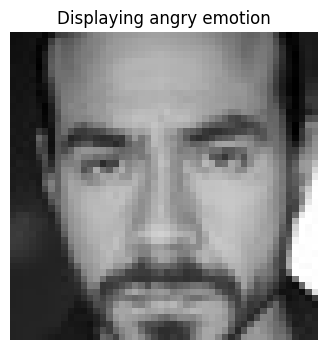

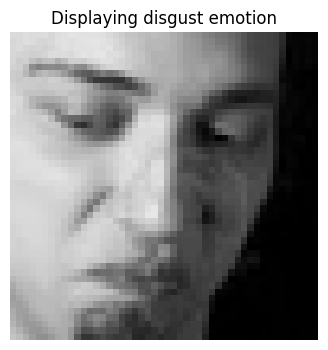

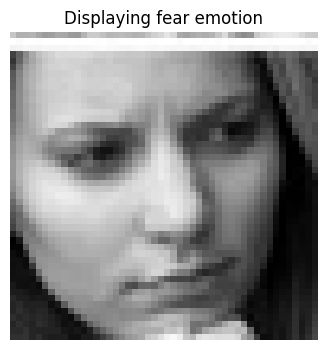

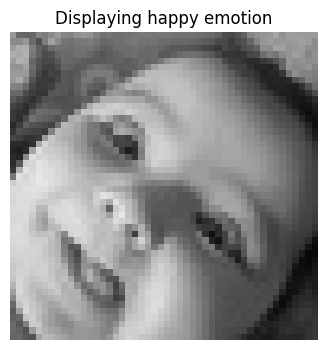

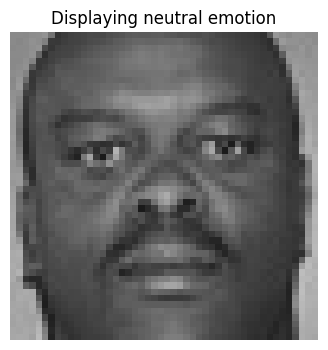

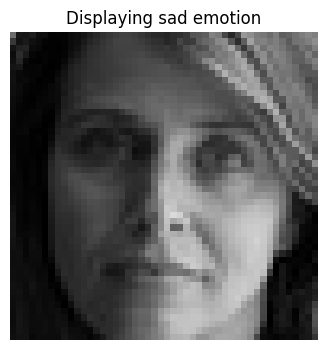

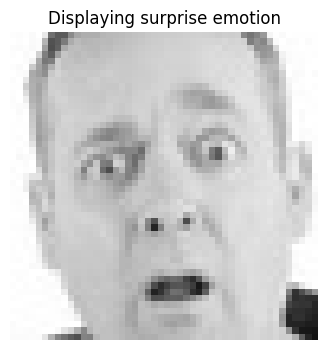

In [12]:
import os
import glob
import cv2
import matplotlib.pyplot as plt

dataset_path = r"/content/drive/MyDrive/Module_5_Specialization_Computer_Vision/DeepFER_datasets/DeepFER_datasets"

# Get all emotion folders inside train
emotion_folders = glob.glob(os.path.join(dataset_path, "train", "*"))

for folder in emotion_folders:
    emotion = os.path.basename(folder)

    # Get first image from the folder
    image_files = glob.glob(os.path.join(folder, "*"))

    if len(image_files) > 0:
        img = cv2.imread(image_files[-2])

        # Convert BGR to RGB for correct display
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title(f"Displaying {emotion} emotion")
        plt.axis("off")
        plt.show()

In [13]:
# specifing new image shape for resnet
img_shape = 224
batch_size = 64

## **ImageDataGenerators for ResNet50V2**

In [14]:
train_preprocessor = ImageDataGenerator(
    rescale=1/255.,
    rotation_range=20,              # better for face angles
    zoom_range=0.25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    brightness_range=[0.7, 1.3],    # important for FER
    horizontal_flip=True,
    fill_mode='nearest',
)

test_preprocessor = ImageDataGenerator(
    rescale=1/255.,
)


## **Data Loaders**

In [15]:
train_data = train_preprocessor.flow_from_directory(
    train_dir,
    class_mode="categorical",
    target_size=(img_shape,img_shape),
    color_mode='rgb',
    shuffle=True,
    batch_size=batch_size,
)

test_data = test_preprocessor.flow_from_directory(
    test_dir,
    class_mode="categorical",
    target_size=(img_shape,img_shape),
    color_mode="rgb",
    shuffle=False,
    batch_size=batch_size,
)

Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.


**Why this step is required?**

1. Face emotions change with lighting, head angle, zoom level, etc.
2. Data augmentation simulates real-world variations → prevents overfitting.
3. rescale=1/255 normalizes pixel values → faster + more stable training.
4. Using augmentations only on training and NOT on test data ensures fair evaluation.

## **Build ResNet50V2 Base Model**

In [16]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

num_classes = train_data.num_classes

base_model = ResNet50V2(
    weights='imagenet',
    include_top=False,
    input_shape=(img_shape, img_shape, 3)
)

base_model.trainable = False  # Freeze entire base

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


- ResNet50V2 already learned powerful visual features from millions of images.
- Freezing layers prevents destroying those learned features.
- Saves training time and prevents overfitting.

In [17]:
# Freezing all layers except last 50
base_model.trainable = True   # allow some layers to be trainable

for layer in base_model.layers[:-50]:
    layer.trainable = False


## **Adding Custom Final Output Layers in ResNet50V2 Model**

In [18]:
# Load the base ResNet50V2 model (without the top classifier)
base_model = ResNet50V2(
    weights='imagenet',
    include_top=False,
    input_shape=(img_shape, img_shape, 3)
)

# Freeze all layers initially
base_model.trainable = False
print("Base ResNet50V2 model loaded and frozen.")

Base ResNet50V2 model loaded and frozen.


The original ResNet50V2 was trained for ImageNet (1000 classes).
The FER dataset has 7 emotion classes, so a new a new classifier head must be added.

| Layer                  | Why it is needed                                           |
| ---------------------- | ---------------------------------------------------------- |
| `Flatten()`            | Converts feature maps into a 1D vector for Dense layers    |
| `Dense(64, relu)`      | Learns task-specific emotional features                    |
| `BatchNormalization()` | Stabilizes training & reduces sensitivity to learning rate |
| `Dropout`              | Prevents overfitting                                       |
| `Dense(7, softmax)`    | Outputs 7 emotion class probabilities                      |


In [19]:
# Get output from base model
x = base_model.output

# Global Average Pooling (reduces feature maps)
x = GlobalAveragePooling2D()(x)

# Regularization to prevent overfitting
x = Dropout(0.3)(x)
x = BatchNormalization()(x)

# Fully Connected Layer
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

# Final Output Layer
outputs = Dense(num_classes, activation='softmax')(x)

# Final ResNet50V2 model
model = Model(inputs=base_model.input, outputs=outputs)

## **Compile the model**

In [20]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 24,100,359 (91.94 MB)

 Trainable params: 530,951 (2.03 MB)

 Non-trainable params: 23,569,408 (89.91 MB)

In [21]:
#Import Callback Libaries
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import tensorflow as tf

# Model Checkpoint (Save Best Model)
checkpoint_path = "ResNet50V2_Best_Model.h5"

checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_accuracy",
    save_best_only=True,
    mode='max',
    verbose=1
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=7,
    restore_best_weights=True,
    verbose=1
)

# Reduce Learning rate on Plateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    verbose=1,
    min_lr=1e-6
)
 # Combine All Callbacks
callbacks = [checkpoint_callback, early_stop, reduce_lr]

# Steps per Epoch Setup
steps_per_epoch = train_data.n // train_data.batch_size
validation_steps = test_data.n // test_data.batch_size


**Why they are required?**

**1. EarlyStopping**
- Stops training when validation accuracy stops improving.
- Prevents overfitting and saves training time.

**2. ReduceLROnPlateau**
- If validation loss is not improving → reduce learning rate.
- Helps model escape plateaus and find a better minimum.

**3. ModelCheckpoint**
- Saves the best model only, not the last one.
- Prevents losing best weights in later bad epochs.

## **Training the ResNet50V2 Model**

In [22]:
# --------------------------------------------
#  TRAINING THE RESNET50V2 MODEL
# --------------------------------------------
ResNet50V2_history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=15,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3067 - loss: 2.1594
Epoch 1: val_accuracy improved from None to 0.45028, saving model to ResNet50V2_Best_Model.h5



Epoch 1: finished saving model to ResNet50V2_Best_Model.h5
450/450 ━━━━━━━━━━━━━━━━━━━━ 656s 1s/step - accuracy: 0.3443 - loss: 1.8867 - val_accuracy: 0.4503 - val_loss: 1.4246 - learning_rate: 0.0010
Epoch 2/15
  1/450 ━━━━━━━━━━━━━━━━━━━━ 56s 126ms/step - accuracy: 0.4375 - loss: 1.3981

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.45028
450/450 ━━━━━━━━━━━━━━━━━━━━ 36s 79ms/step - accuracy: 0.4375 - loss: 1.3981 - val_accuracy: 0.4482 - val_loss: 1.4277 - learning_rate: 0.0010
Epoch 3/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3975 - loss: 1.5832
Epoch 3: val_accuracy improved from 0.45028 to 0.48267, saving model to ResNet50V2_Best_Model.h5



Epoch 3: finished saving model to ResNet50V2_Best_Model.h5
450/450 ━━━━━━━━━━━━━━━━━━━━ 622s 1s/step - accuracy: 0.4042 - loss: 1.5566 - val_accuracy: 0.4827 - val_loss: 1.3592 - learning_rate: 0.0010
Epoch 4/15
  1/450 ━━━━━━━━━━━━━━━━━━━━ 56s 126ms/step - accuracy: 0.4062 - loss: 1.5378
Epoch 4: val_accuracy did not improve from 0.48267
450/450 ━━━━━━━━━━━━━━━━━━━━ 35s 79ms/step - accuracy: 0.4062 - loss: 1.5378 - val_accuracy: 0.4814 - val_loss: 1.3599 - learning_rate: 0.0010
Epoch 5/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4208 - loss: 1.5072
Epoch 5: val_accuracy improved from 0.48267 to 0.48849, saving model to ResNet50V2_Best_Model.h5


...


Epoch 9: finished saving model to ResNet50V2_Best_Model.h5
450/450 ━━━━━━━━━━━━━━━━━━━━ 574s 1s/step - accuracy: 0.4352 - loss: 1.4677 - val_accuracy: 0.5101 - val_loss: 1.3045 - learning_rate: 0.0010
Epoch 10/15
  1/450 ━━━━━━━━━━━━━━━━━━━━ 1:04 143ms/step - accuracy: 0.4375 - loss: 1.4139
Epoch 10: val_accuracy improved from 0.51009 to 0.51051, saving model to ResNet50V2_Best_Model.h5



Epoch 10: finished saving model to ResNet50V2_Best_Model.h5
450/450 ━━━━━━━━━━━━━━━━━━━━ 31s 68ms/step - accuracy: 0.4375 - loss: 1.4139 - val_accuracy: 0.5105 - val_loss: 1.3042 - learning_rate: 0.0010
Epoch 11/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4389 - loss: 1.4586
Epoch 11: val_accuracy improved from 0.51051 to 0.51634, saving model to ResNet50V2_Best_Model.h5



Epoch 11: finished saving model to ResNet50V2_Best_Model.h5
450/450 ━━━━━━━━━━━━━━━━━━━━ 590s 1s/step - accuracy: 0.4383 - loss: 1.4592 - val_accuracy: 0.5163 - val_loss: 1.2960 - learning_rate: 0.0010
Epoch 12/15
  1/450 ━━━━━━━━━━━━━━━━━━━━ 1:06 148ms/step - accuracy: 0.4531 - loss: 1.5029
Epoch 12: val_accuracy improved from 0.51634 to 0.51705, saving model to ResNet50V2_Best_Model.h5



Epoch 12: finished saving model to ResNet50V2_Best_Model.h5
450/450 ━━━━━━━━━━━━━━━━━━━━ 40s 88ms/step - accuracy: 0.4531 - loss: 1.5029 - val_accuracy: 0.5170 - val_loss: 1.2957 - learning_rate: 0.0010
Epoch 13/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4417 - loss: 1.4507
Epoch 13: val_accuracy did not improve from 0.51705
450/450 ━━━━━━━━━━━━━━━━━━━━ 533s 1s/step - accuracy: 0.4430 - loss: 1.4503 - val_accuracy: 0.5149 - val_loss: 1.2852 - learning_rate: 0.0010
Epoch 14/15
  1/450 ━━━━━━━━━━━━━━━━━━━━ 1:07 151ms/step - accuracy: 0.3750 - loss: 1.5754
Epoch 14: val_accuracy did not improve from 0.51705
450/450 ━━━━━━━━━━━━━━━━━━━━ 30s 66ms/step - accuracy: 0.3750 - loss: 1.5754 - val_accuracy: 0.5149 - val_loss: 1.2857 - learning_rate: 0.0010
Epoch 15/15
450/450 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4407 - loss: 1.4381
Epoch 15: val_accuracy improved from 0.51705 to 0.51875, saving model to ResNet50V2_Best_Model.h5



Epoch 15: finished saving model to ResNet50V2_Best_Model.h5
450/450 ━━━━━━━━━━━━━━━━━━━━ 543s 1s/step - accuracy: 0.4436 - loss: 1.4411 - val_accuracy: 0.5188 - val_loss: 1.2741 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 15.


* Model updates weights by learning patterns from training images.
* Validation data monitors whether the model is generalizing.

## **Evaluate ResNet50V2 Model**

In [23]:
from keras.models import load_model

ResNet50V2_Model = load_model("ResNet50V2_Best_Model.h5")

In [24]:
# --------------------------------------------
# 📌 MODEL EVALUATION ON TEST DATA
# --------------------------------------------
ResNet50V2_score = ResNet50V2_Model.evaluate(test_data)

print(f"Test Loss     : {ResNet50V2_score[0]:.5f}")
print(f"Test Accuracy : {ResNet50V2_score[1] * 100:.2f}%")


111/111 ━━━━━━━━━━━━━━━━━━━━ 42s 321ms/step - accuracy: 0.5192 - loss: 1.2735
Test Loss     : 1.27350
Test Accuracy : 51.92%


* Gives final performance on unseen test images.
* Helps determine whether your model is ready for deployment.

In [25]:
# --------------------------------------------
# 📌 PLOT TRAINING & VALIDATION CURVES
# --------------------------------------------
import matplotlib.pyplot as plt

def plot_curves(history):

    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r^-', label='Validation Accuracy')
    plt.title("Training vs Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r^-', label='Validation Loss')
    plt.title("Training vs Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()


This Shows trends of training/validation accuracy and loss.

Helps detect:

* overfitting
* underfitting
* learning rate issues
* whether more training is required

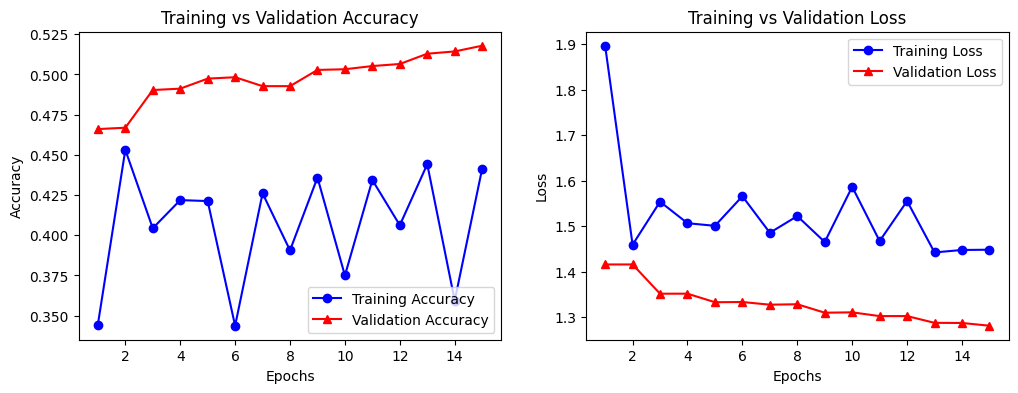

In [ ]:
# Plot The Curve
plot_curves(ResNet50V2_history)

## **Generate Predictions Correctly**

In [27]:
# --------------------------------------------
# 📌 PREDICTIONS
# --------------------------------------------
from tensorflow.keras.models import load_model

model = load_model('/content/ResNet50V2_Best_Model.h5')

pred_probs = model.predict(test_data)

ResNet50V2_Predictions = np.argmax(pred_probs, axis=1)

111/111 ━━━━━━━━━━━━━━━━━━━━ 40s 313ms/step


## **Confusion Matrix**

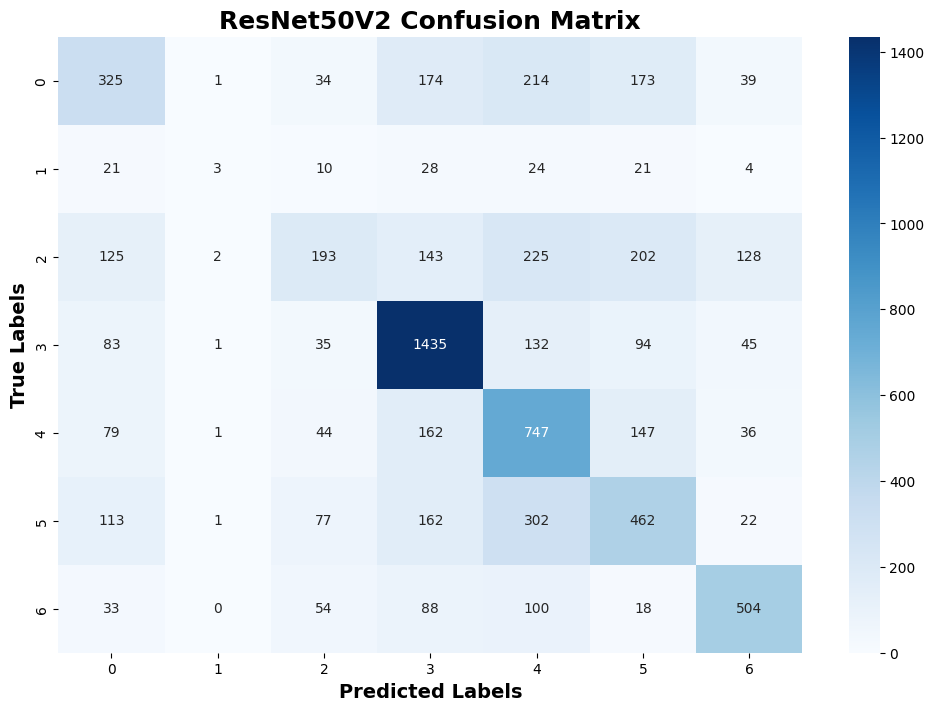

In [28]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_data.labels, ResNet50V2_Predictions)

plt.figure(figsize=(12,8))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')

plt.xlabel("Predicted Labels", fontsize=14, fontweight='bold')
plt.ylabel("True Labels", fontsize=14, fontweight='bold')
plt.title("ResNet50V2 Confusion Matrix", fontsize=18, fontweight='bold')
plt.show()


A confusion matrix helps you understand class-wise performance:

* Which emotions are misclassified?
* Is the model confusing fear vs surprise?
* Are minority classes underperforming?
* It gives a much deeper understanding than accuracy alone.

## **Class-wise Accuracy**

In [29]:
classes = list(test_data.class_indices.keys())

cm_df = pd.DataFrame(cm, index=classes, columns=classes)
display(cm_df)


,angry,disgust,fear,happy,neutral,sad,surprise
angry,325,1,34,174,214,173,39
disgust,21,3,10,28,24,21,4
fear,125,2,193,143,225,202,128
happy,83,1,35,1435,132,94,45
neutral,79,1,44,162,747,147,36
sad,113,1,77,162,302,462,22
surprise,33,0,54,88,100,18,504


## **Final Summary**

| Step                           | Purpose                                        |
| ------------------------------ | ---------------------------------------------- |
| Data Augmentation              | Prevents overfitting & improves generalization |
| Transfer Learning (ResNet50V2) | Uses powerful pre-learned features             |
| Freeze Layers                  | Keeps useful ImageNet knowledge                |
| Custom Head                    | Adapts model for 7-class emotion detection     |
| Callbacks                      | Makes training stable and efficient            |
| Model Training                 | Learns on your FER dataset                     |
| Evaluation                     | Measures performance on unseen data            |
| Plot Curves                    | Helps diagnose overfitting/underfitting        |
| Confusion Matrix               | Checks class-wise model behavior               |


## **Testing With Random Validation Data**

### Emotion Class Names

In [30]:
Emotion_Classes = ['Angry','Disgust','Fear','Happy','Neutral','Sad','Surprise']

### Creating Test Data Generator

In [31]:
# Shuffling Test Data to show diffrent classes
test_preprocessor = ImageDataGenerator(
        rescale = 1 / 255.,
    )

test_generator = test_preprocessor.flow_from_directory(
    test_dir,
    class_mode="categorical",
    target_size=(img_shape,img_shape),
    color_mode="rgb",
    shuffle=True,
    batch_size=batch_size,
)

Found 7066 images belonging to 7 classes.


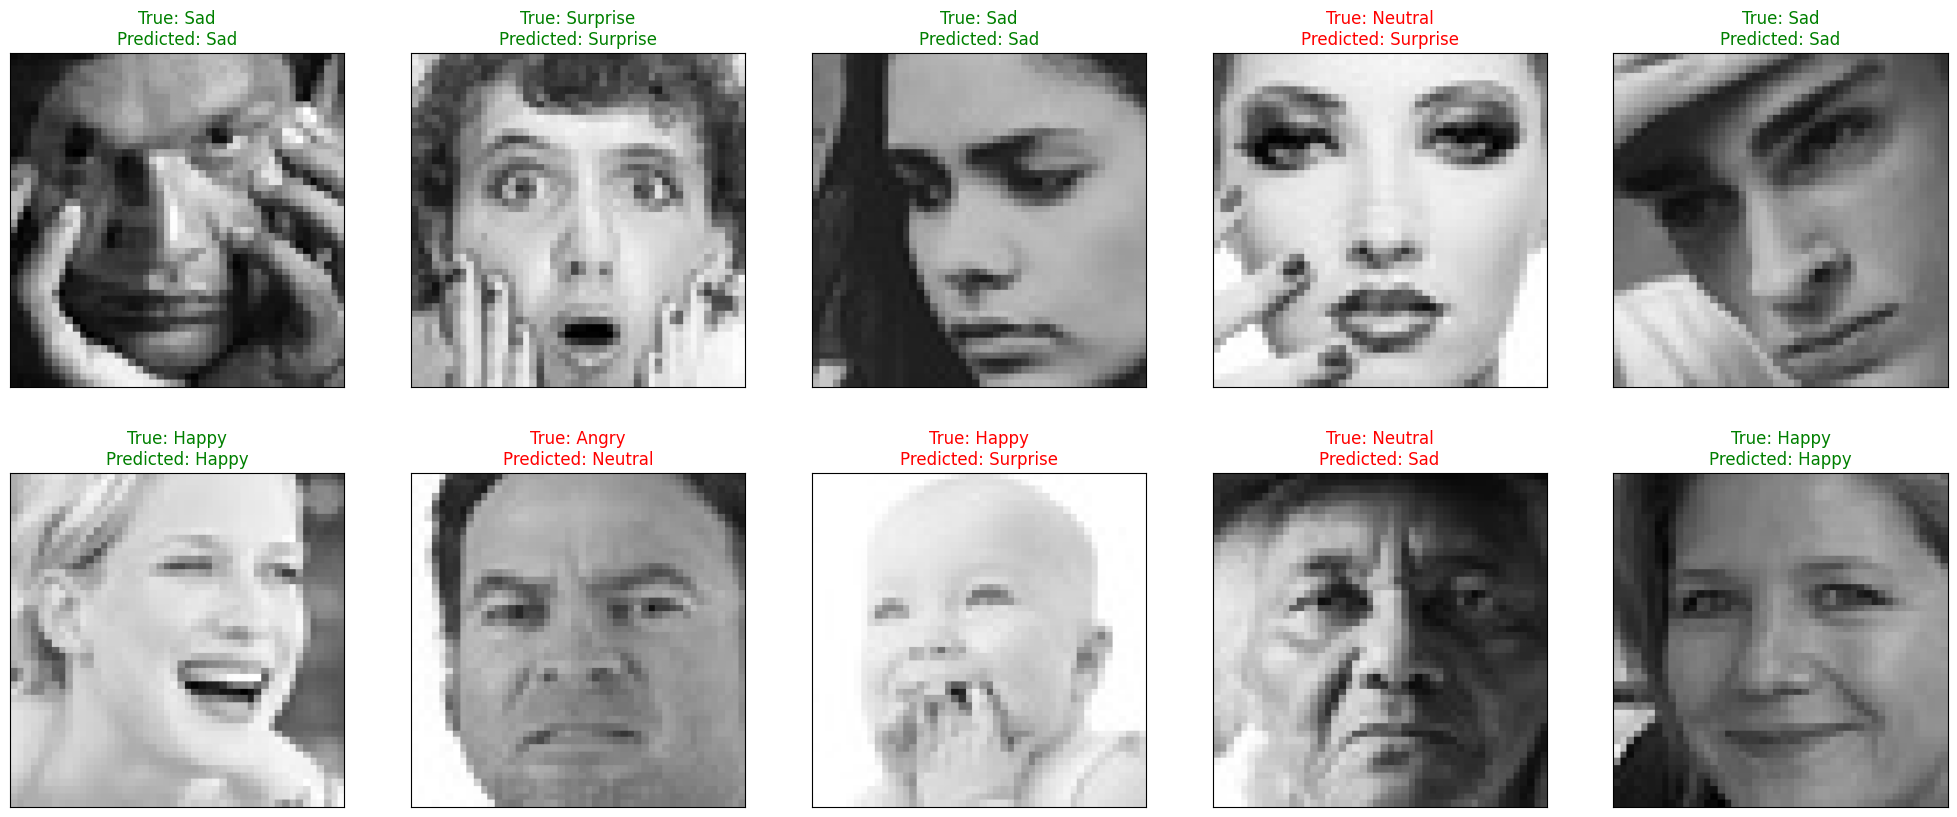

<Figure size 640x480 with 0 Axes>

In [32]:
# Display 10 random pictures from the dataset with their labels

Random_batch = np.random.randint(0, len(test_generator) - 1)

Random_Img_Index = np.random.randint(0, batch_size - 1 , 10)

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(25, 10),
                        subplot_kw={'xticks': [], 'yticks': []})

for i, ax in enumerate(axes.flat):

    Random_Img = test_generator[Random_batch][0][Random_Img_Index[i]]

    Random_Img_Label = np.argmax(test_generator[Random_batch][1][Random_Img_Index[i]])

    Model_Prediction = np.argmax(ResNet50V2_Model.predict( tf.expand_dims(Random_Img, axis=0) , verbose=0))

    ax.imshow(Random_Img)

    if Emotion_Classes[Random_Img_Label] == Emotion_Classes[Model_Prediction]:
          color = "green"
    else:
          color = "red"
    ax.set_title(f"True: {Emotion_Classes[Random_Img_Label]}\nPredicted: {Emotion_Classes[Model_Prediction]}", color=color)
plt.show()
plt.tight_layout()


In [33]:
model.save("/content/drive/MyDrive/Module_5_Specialization_Computer_Vision/ResNet50V2_Model.h5")